In [1]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import expm_multiply
from utils import *
from os.path import join
import matplotlib.pyplot as plt
from math import comb

In [2]:

DATA_DIR = "data"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)


In [3]:
def linear_transport(N, T, c, num_time_points, R, mu, sigma):
    psi_0 = np.zeros(N, dtype=np.complex64)
    # psi_0[1] = 1
    # Initialize to Gaussian
    for i in range(N):
        psi_0[i] = np.exp(-0.5 * ((i / (N-1) - mu) / sigma) ** 2)
    # for i in range(N):
    #     psi_0[i] = comb(n, i)
    psi_0 /= np.linalg.norm(psi_0)

    dx = R / (N - 1)

    h = np.ones(N-1)
    H = diags([-1j * h, 1j * h], [1, -1]).tocsc()
    # H[0,0] = 0
    # H[-1,-1] = 0
    H[0,-1] = 1j
    H[-1,0] = -1j
    # plt.matshow(H.toarray().imag)




    # H = diags([-1j * x, 1j * x], [1, -1]).tocsc()
    # H[0,-1] = 
    # H[-1,0] = -1j


    # plt.matshow(H.toarray().imag)
    # plt.show()
    H *= (c / (2 * dx))
    # H = (c / ())
    psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_time_points)

    return psi

In [4]:
# N = 5
# T = 2
# R = 1
# c = 1
# mu = int(0.2 * (N-1)) / (N-1)
# sigma = 0.04
# psi = linear_transport(N, T, c, 6, R, mu, sigma)

In [5]:
N = 128
T = 2
R = 1
c = 1
mu = int(0.2 * (N-1)) / (N-1)
sigma = 0.1
num_time_points = 20
psi = linear_transport(N, T, c, num_time_points, R, mu, sigma)

/home/jli0108/anaconda3/lib/python3.10/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


In [6]:

dist = np.abs(psi) ** 2
x = np.linspace(0, 1, N)
t_vals = np.linspace(0, T, num_time_points)

exp_val = dist @ x


In [7]:

dist = np.abs(psi) ** 2
x = np.linspace(0, 1, N)
t_vals = np.linspace(0, T, num_time_points)

exp_val = dist @ x

In [8]:
# plt.plot(t_vals, exp_val, '-o')
# plt.show()

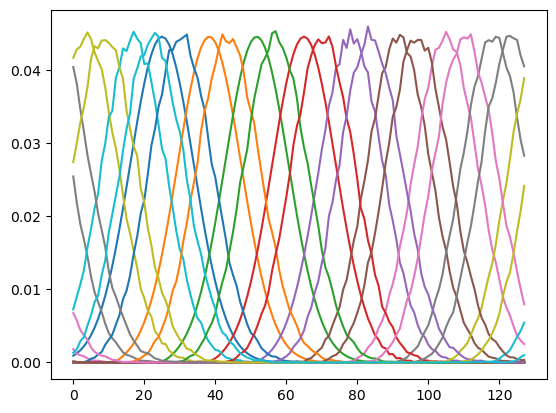

In [9]:
for i in np.arange(0, num_time_points, 1):
    # plt.plot(psi[i].real, label=f"real part, i={i}")
    # print(psi[i,-1])
    plt.plot(np.abs(psi[i]) ** 2)
    # print(np.linalg.norm(psi[i]))
# plt.legend()
plt.show()

Test 2d example from recent paper

In [64]:
N = 32
y_vals = np.linspace(0, 1, N)
x_, y_ = np.meshgrid(np.linspace(0,1,N), y_vals, indexing='xy')
T = 8
num_time_points = 5
t_vals = np.linspace(0, T, num_time_points)

/home/jli0108/anaconda3/lib/python3.10/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


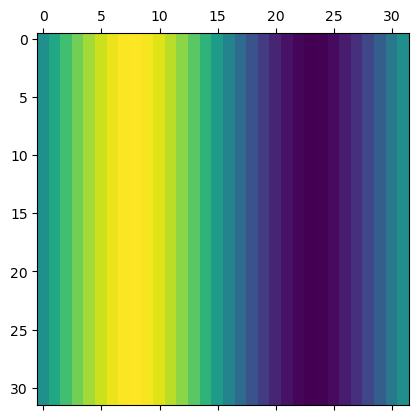

In [67]:

dx = 1 / (N - 1)

h = np.ones(N-1)
H_1d = diags([-1j * h, 1j * h], [1, -1]).tocsc()
# H[0,0] = 0
# H[-1,-1] = 0
H_1d[0,-1] = 1j
H_1d[-1,0] = -1j
# plt.matshow(H.toarray().imag)




# H = diags([-1j * x, 1j * x], [1, -1]).tocsc()
# H[0,-1] = 
# H[-1,0] = -1j


# plt.matshow(H.toarray().imag)
# plt.show()
H_1d *= (c / (2 * dx))

D = diags(4 * y_vals * (1 - y_vals))
H = kron(D, H_1d)


psi_0 = np.sin(2 * np.pi * x_)
psi_0 /= np.linalg.norm(psi_0)
plt.matshow(psi_0)
plt.show()


psi = expm_multiply(-1j * H, psi_0.flatten(), 0, T, num=num_time_points)

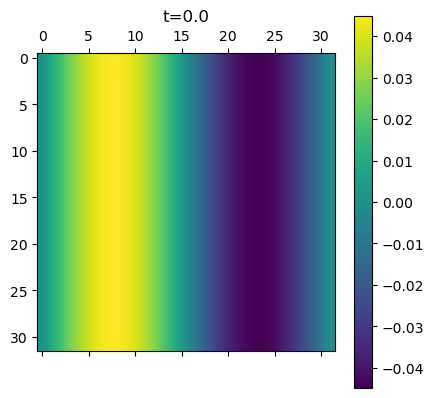

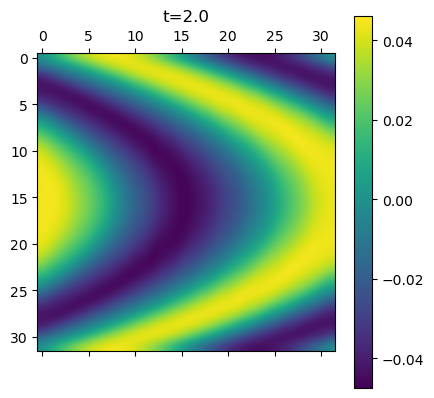

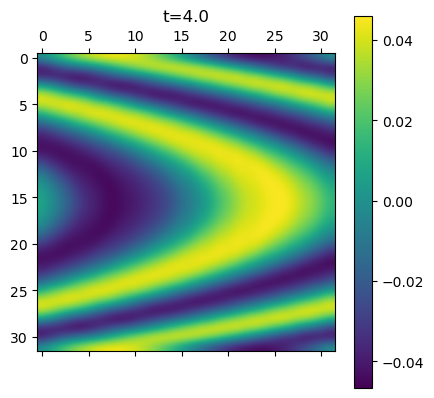

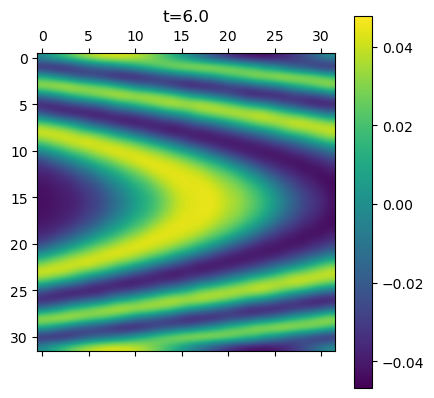

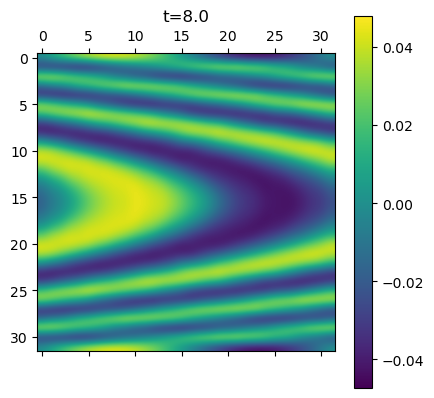

In [68]:
for i in range(num_time_points):
    plt.matshow(np.reshape(psi[i].real, (N,N)), interpolation="bicubic")
    plt.title(f"t={t_vals[i]}")
    plt.colorbar()
    plt.show()

In [10]:
N_vals = np.array([32, 64, 128, 256, 400, 512])
h_vals = 1 / (N_vals - 1)

error_2d = []

for N in N_vals:

    # N = 256
    n = N-1
    R = 1
    num_time_points = 16

    mu = int(0.2 * (N-1)) / (N-1)
    sigma = 0.04

    T = 1
    c = 0.4

    psi = linear_transport(N, T, c, num_time_points, R, mu, sigma)

    psi_true = np.zeros((num_time_points, N))
    for i in range(num_time_points):
        t = np.linspace(0, T, num_time_points)[i]
        for j in range(N):
            # print(j / (N-1))
            psi_true[i,j] = np.exp(-0.5 * ((j / (N-1) - c * t - mu) / sigma) ** 2)

        psi_true[i] /= np.linalg.norm(psi_true[i])

    error = np.zeros((num_time_points, N))

    for i in range(num_time_points):
        error[i] = np.abs(psi_true[i] - psi[i].real)

    avg_error = np.average(error, axis=1)
    error_2d.append(avg_error)


In [11]:
error_2d = np.array(error_2d)

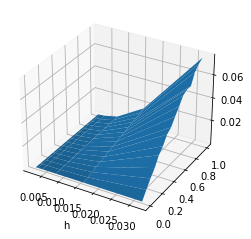

In [6]:
X, Y = np.meshgrid(h_vals, np.linspace(0, T, num_time_points), indexing='ij')



fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

surf = ax.plot_surface(X, Y, error_2d)
plt.xlabel("h")
plt.show()

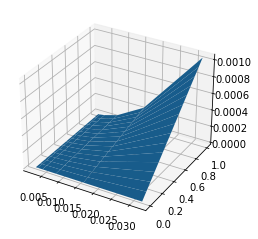

In [7]:
X, Y = np.meshgrid(h_vals, np.linspace(0, T, num_time_points), indexing='ij')

Z = Y * X ** 2

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

surf = ax.plot_surface(X, Y, Z)
plt.show()

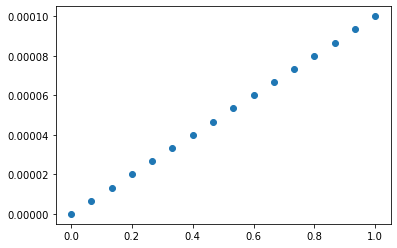

In [8]:
plt.scatter(np.linspace(0, T, num_time_points), avg_error)
plt.show()

# check error is O(h^2)

In [9]:
N_vals = np.array([16, 32, 64, 128, 256, 512])
h_vals = 1 / (N_vals-1)
avg_error_vals = []
num_time_points = 2

for i in range(len(N_vals)):
    
    N = N_vals[i]
    h = h_vals[i]
    
    psi = linear_transport(N, T, c, num_time_points, R, mu, sigma)

    psi_true = np.zeros(N, dtype=np.complex64)
    # Initialize to Gaussian
    for i in range(N):
        psi_true[i] = np.exp(-0.5 * ((i / (N-1) - c * T - mu) / sigma) ** 2)

    psi_true /= np.linalg.norm(psi_true)

    error = np.abs(psi_true - psi[1].real)

    avg_error_vals.append(np.average(error))

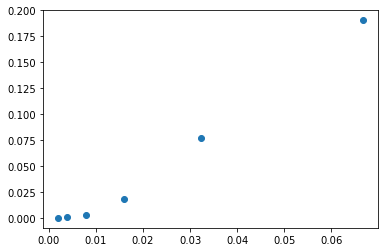

In [10]:
plt.scatter(h_vals, avg_error_vals)
plt.show()

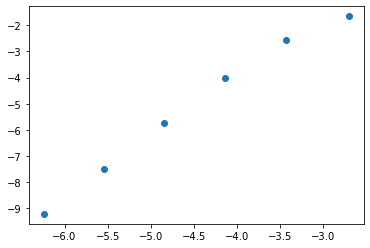

In [11]:
plt.scatter(np.log(h_vals), np.log(avg_error_vals))
plt.show()

In [12]:
np.polyfit(np.log(h_vals), np.log(avg_error_vals), 1)

array([2.1963854 , 4.73790055])

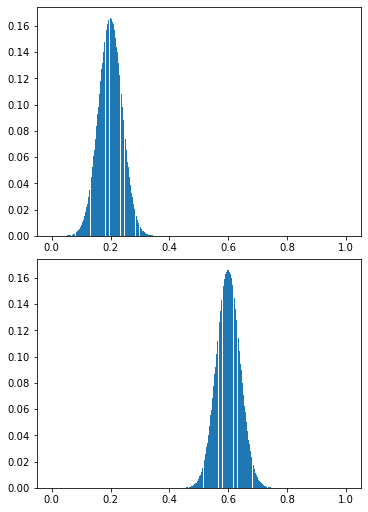

In [13]:
fig, axs = plt.subplots(num_time_points, 1, constrained_layout=True, figsize=(5,7))

for i in range(num_time_points):
    axs[i].bar(np.linspace(0, 1, N), psi[i].real, width=0.9/N)
plt.show()

# fig, axs = plt.subplots(num_time_points, 2, constrained_layout=True, figsize=(5,7))

# for i in range(num_time_points):
#     axs[i,0].bar(np.linspace(0, 1, N), psi[i].real, width=0.9/N)
#     axs[i,1].bar(np.linspace(0, 1, N), np.abs(psi[i]) ** 2, width=0.9/N)
# plt.show()

In [ ]:
# Rydberg atoms

C6 = 862690 * 2 * np.pi # Rydberg interaction constant (MHz⋅μm^6)
R = 4.0 # Lattice scale / μm
Ω = 2 * np.pi * 4.0 # (Global) Rabi frequency (MHz)
ts = 4.0 # Simulation time (μs)

times = np.linspace(0, ts, num_time_points)

In [8]:

qubit_locations = np.zeros(n)
for k in range(n):
    qubit_locations[k] = R * k

detuning = np.zeros(n)
for i in range(n):
    if i % 2 == 0:
        for j in range(int((n-i)/2)):
            detuning[i] += C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[i + (2 * j + 1)]) ** 6
        for j in range(int(i/2)):
            detuning[i] += C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[i - (2 * (j + 1))]) ** 6
    else:
        for j in range(int((n-1-i)/2)):
            detuning[i] += C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[i + (2 * (j + 1))]) ** 6
        for j in range(int((i+1)/2)):
            detuning[i] += C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[i - (2 * j + 1)]) ** 6


V = np.zeros((n, n))
for i in range(n):
    for j in range(i):
        V[i,j] = C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[j]) ** 6

phase = np.array([(-1) ** k for k in range(n)])

H = 0.5 * Ω * sum_h_y(n, phase) - sum_delta_n(n, detuning) + sum_V_nn(n, V)


In [9]:

# H = driving_term(n, np.linspace(0, 1, n) * Ω, phase) - sum_delta_n(n, detuning) + sum_V_nn(n, V)

In [10]:
# H1 = np.zeros((N,N), dtype=np.complex64)

# bitstring_1 = [k % 2 for k in range(n)]
# for i in range(n+1):

#     bitstring_2 = [k % 2 for k in range(n)]
#     for j in range(n+1):
        
#         H1[i,j] = H[bitstring_to_int(bitstring_1), bitstring_to_int(bitstring_2)]
#         if j < n:
#             bitstring_2[j] = 1 - bitstring_2[j]
    
#     if i < n:
#         bitstring_1[i] = 1 - bitstring_1[i]

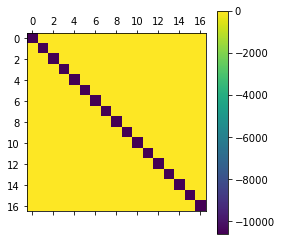

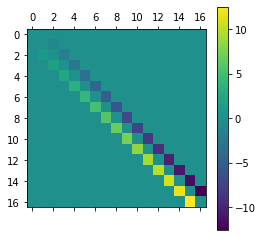

In [11]:
# plt.matshow(H1.real)
# plt.colorbar()
# plt.show()

# plt.matshow(H1.imag)
# plt.colorbar()
# plt.show()

In [ ]:
psi_0 = np.zeros(2 ** n)
bitstring = [k % 2 for k in range(n)]
for i in range(n+1):

    psi_0[bitstring_to_int(bitstring)] += comb(n, i)
    
    if i < n:
        bitstring[i] = 1 - bitstring[i]

psi_0 /= np.linalg.norm(psi_0)

psi = expm_multiply(-1j * H, psi_0, start=0, stop=ts, num=num_time_points)